# 01. PyTorch End-to-End Workflow

### Overview & Core Concepts
* **Data Preparation & Splits:** Generating numerical feature representations ($X$) and ground-truth targets ($y$), followed by training and testing set partitioning.
* **Model Architecture (`torch.nn`):** Building parametric models via subclassing `nn.Module`, managing weights and biases (`nn.Parameter`), and defining forward computational graphs within `forward()`.
* **Optimization & Loss Objectives:** Comparing error metrics via loss functions (`nn.L1Loss`, `nn.MSELoss`) and updating parameter trajectories via optimizers (`SGD`, `Adam`).
* **Execution Loops:** Implementing standard training sequences (forward pass $\rightarrow$ loss calculation $\rightarrow$ `zero_grad()` $\rightarrow$ `backward()` backpropagation $\rightarrow$ `step()` gradient descent) and evaluation loops under `torch.inference_mode()`.
* **State & Regularization Mechanics:** Mode-dependent behaviors (`model.train()` vs. `model.eval()`) for Inverted Dropout and Batch Normalization (internal covariate shift mitigation via running statistics).
* **Model Serialization:** Persisting and restoring learned parameter mappings using `torch.save()`, `torch.load()`, and `state_dict()` deserialization.

-------------
-------------

In [1]:
# PyTorch Workflow

In [2]:
what_are_we_covering = {1: "data (prepare and load)",
                        2: "build model",
                        3: "fitting the model to data (training)",
                        4: "making predictions and evaluating the model (inference)",
                        5: "saving and loading a model",
                        6: "putting it all together"}
what_are_we_covering

# 1. torchvision.transforms, torch.utils.data.Dataset, torch.utils.data.DataLoader
# 2. torch.nn, torch.nn.Module, torchvision.models (optimizer - torch.optim)
# 4. torchmetrics
# 5. experimentation - torch.utils.tensorboard

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating the model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [3]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.10.0+cpu'

## 1. Data (preparing and loading)

Data can be almost anything... in ML

* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine Learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.


- **Parameters** are internal variables that the model "learns" from the data during training. They define the strength of connections between neurons and the threshold for their activation(like the "knobs and dials" of the machine).

- There are 2 basic paramenters: `Weights(w)` and `Biases(b)`.
Where weights control the strength between the connection between two neurons. Biases allow the activation funciton to shift left/right, effectively setting up a "threshold" for when a neuron should fire regardless of input values.


In [4]:
# We will use linear regression formula to make a straight line with known parameters.
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data 
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias # Ideal output we know it but machine doesnt it will learn this equation(relation)

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

## Splitting data into training and test sets

3 types of tests:
* Training Set(Course Materials)(~60-80%) - Always used
* Validation Set(Practice Exam) - Tunes model patterns(~10-20%) - Often but not always used
* Test Set(Final Exam) - See if the model is ready for the wild(~10-20%) - Always used

**Generalization** - The ability for a machine learning model to perform well on data it hasn't seen before.

In [5]:
 # lets create train/test 80-20 split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Building a Function to Visualize our Data

In [6]:
 def plot_predictions(train_data = X_train,
                      train_labels = y_train,
                      test_data = X_test,
                      test_labels = y_test,
                      predictions = None):
     """
     Plots training data, test data and compares predictions
     """
     plt.figure(figsize = (10,7)) #its in inches but our screen shows it as per DPI(Dots per Inch) settings (we can change the default by "plt.rcParams['figure.dpi'] = 100")
     # plt.rcParams['figure.dpi'] = 100
     # plt.rcdefaults()(all features default) or plt.rcParams['figure.dpi'] = mpl.rcParamsDefault['figure.dpi'] for reverting back to default
     
     # define training data in blue
     plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

     # define test data in green
     plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Testing data")

     # Are there predictions?
     if predictions is not None:   # its needed coz if predictions not there Python would crash
         # Plot the predictions if they exist in red
         plt.scatter(test_data, predictions, c = "r", s = 5, label = "Predictions")  # other font properties{"weight":"bold"}
                                                                             
     # Show the legend
     plt.legend(prop={"size":14});   #prop stands for properties(Font properties)

# plt.legend: displays the labels specified in the label parameters of the scatter calls
# prop = {"size":14}: sets the font size of the legend text to 14 for better readability
# ; in jupyter environment prevents matlplotlib from printing the memory address of the object(), 
#           (e.g., <matplotlib.legend.Legend at ...>), keeping the output clean.

# plt.scatter creates a scatter plot
# s = 4 is marker size(relatively small dots)
# label attaches a name for the legend(map key or labels)

# Scatter plot is the dispersal of scattered dots to show the relationship between variables.

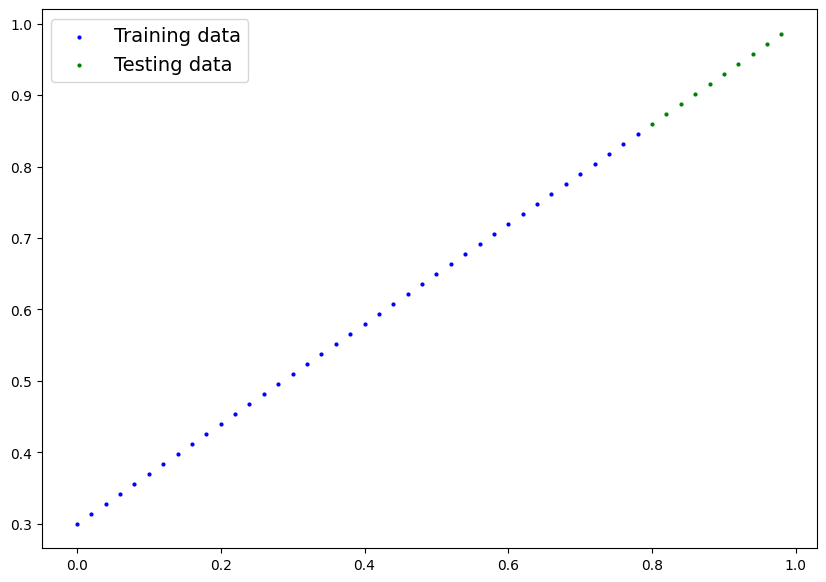

In [7]:
plot_predictions();

## 2. Build Model
(PyTorch Model)

- What our model does:
  * Start with random values(weights & bias)
  * Look at the training data and adjust the random values to better represent (or get closer to) the ideal values
- How does it(model) do so: (Through two main algorithms)
  * Gradient descent
  * Backpropagation

In [8]:
# class LinearRegressionModel(nn.Module); (nn.module): This is inheitance. By putting nn.module in patentheses, we're telling pytorch that
# our class is a child class of PyTorch's base neural network class. This gives us access to essential tools like 
# .parameters(), .to(device), and the ability to track gradients automatically.

# def __init__(self): This is the constructor. It runs the moment we create an instance of the model(e.g., model = LinearRegressionModel()).
#                     Its when we define the "parts" of our model(the weights and biases)

# super().__init__(): This is crucial. It calls the __init__ method of the parent class (nn.Module). Without this, the internal PyTorch
#                     machinery that tracks our layers and parameters wont be initialized, and our code will throw errors.

# self.weights & self.bias: We're creating a variable that belongs to this specific model instance
# nn.Parameter: It tells PyTorch:"This tensor isnt a regular array of numbers but a part of the model that should be updated during training"
# torch(1, ...): It creates a tensor with 1 random number from a Normal Distribution(mean 0 , variance 1). We start this as model has 
#               to start somewhere before it "learns" the true values.

# forward block
# forward: It is a reserved method name in PyTorch.It defines the "computation" that happens when we pass data into our model(e.g: model(X_train))
# x: torch.Tensor: This is a type hint. It says "the input x should be a PyTorch tensor"
# -> torch.Tensor: Another hint saying: "this function will return a tensor"
# return ... : Actual Linear Regression Formula. As self.weights and self.bias are tensors PyTorch performs this math using Vectorization.

In [9]:
# Create Linear Regression model class

## nn.module is the base class for all neural network modules, our models must also subclass this class
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()

        # Initialize model parameters(here we knnow, in bigger datasets we might not know what are they like image datasets)
        self.weights = nn.Parameter(torch.randn(1,              # start with a random weight and try to adjust it to the ideal weight
                                               requires_grad = True,
                                               dtype = torch.float)) # PyTorch default so PyTorch loves it
        self.bias = nn.Parameter(torch.randn(1,                # start with a random bias and try to adjust it to the ideal biias  
                                            requires_grad = True,
                                            dtype = torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:   # "x" is the input data
        return self.weights * x + self.bias

#torch.randn: return a tensor with random values with normal distribution with mean 0 and vaiance 1
#while torch.rand: returns a tensor filled with random numbers from a uniform distribution on the interval [0,1)

# The model parameters could be different layers from torch.nn, single parameters, hard-coded values or functions
# requires_grad=True: PyTorch will track the gradients of this specific parameter for use with torch.autgrad and 
#                     gradient descent(for many toch.nn modules, requires_grad = True is set by default)

# Any subclass of nn.Module needs to override forward() (this defines the forward computation of the model)



# torch.randn range is [0,1) and every no. have an equal chance to appear, torch.rand(-inf,+inf) but usually(-3,3) but no equal chance
# in rand only positive numbers many appear in early stages of training and may bias the model. but in randn there is mix of +/- values both(centered at 0)
# and also activation function like tanh and sigmoid works best around values "normalized"(centered aroud zero)

## PyTorch model building essentials
* `torch.nn` - contains all of the building blocks for computational graphs(a neural network can be considered a computational graph(a series of computations executed in a particular way)) (base class for nn in PyTorch)
* `torch.nn.Parameter` - what parameters should our model try and learn, often a "PyTorch layer" from torch.nn will "set this for us"
* `torch.nn.Module` - The base class for all neural network modules, if we subclass it, we should overwrite forward()
* `torch.optim` - This is where the optimizers in PyTorch live, they will help with gradient descent
* `def forward()` - All nn.Module subclasses require us to overwrite forward(), as it defines what happens in forward computation.
* `torch.utils.data.Dataset` - Represents a map between key(label) and sample(features) pairs of our data. Such as images and their associated labels.
* `torch.utils.data.Dataloader` - Creates a Python iterable over a torch Dataset(allows us to iterate over our data).

### Checking the contents of our PyTorch LR model

We can check our model parameters or what's inside our model using `.parameters()`

In [10]:
 # Create a random seed(we're creating it to be reproducible)
torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()

# Check out the parameters
# model_0.parameters() # it will generate a 'generator' object. To actually see the contents a list is needed
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# List named parameters
model_0.state_dict()

# Purpose: Extracts weights and biases; Use Case: Saving, loading or inspecting model parameters.
# Its a Python library dictionary object that maps each layer of our model to its current parameter tensors(the weight and biases that we defined)
# Only layers with learnable parameters are present inside it. Layers that dont learn anything like - nn.ReLU/nn.Dropout - willn't appear in the dictionary

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [12]:
weight, bias # The above values must be as close as these ideal values for the model to be a better fit

(0.7, 0.3)

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, lets see how well it predicts `y_test` bases on `X_test`.

When we pass data through our model, its going to run it through the `forward()` method

In [13]:
# Make predictions with model

# Its a context manager that wraps around our code while making predictions(not training) and it disables gradient tracking. Since we aren't
# training the model but making inference so we dont need to track gradients. #torch.no_grad() also does it but torch.inference_mode() is 
# new and faster. (calculating gradients is a quite timely process which we dont need as well during inference)
with torch.inference_mode():
    y_preds = model_0(X_test)
    
# print("X_test: ", X_test)
print("y_test: ", y_test)
print("y_pred: ", y_preds)    # P.S. a really bad model

y_test:  tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])
y_pred:  tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


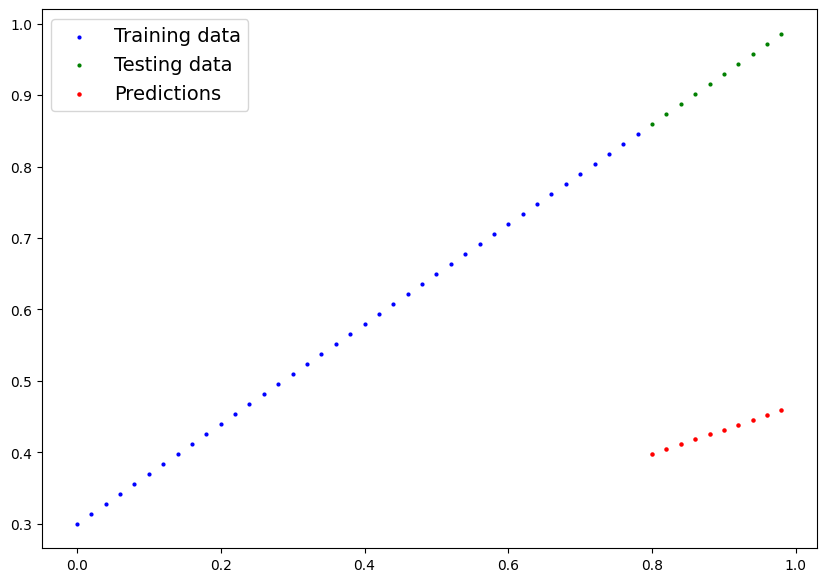

In [14]:
plot_predictions(predictions = y_preds)  #can use **kwargs(keyword arguments at the last of function arguments) to pass like s=5 from here

---

## 3. Train Model

- The whole idea of training if for a model to move from some *unknown* parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation of the data.

- One way to measure how poor or how wrong our model's predictions are is to use a loss function.
- Note: `Loss function` may also be called as `cost function` or `criterion` in different areas.

### Things we need to train a model:

1. **Loss Function:** A function to measure how wrong our model's predictions are compared to the ideal outputs(lower is better).
2. **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters(e.g: weight & bias) to improve the loss fuction.
      * Inside the optimizer we'll often have to set two parameters:
           * `params` - the model parameters we'd like to optimize, e.g: `params=model_0.parameters()`
           * `lr`(learning rate) - the learning rate is the hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in a small changes, a large `lr` results in lrage changes)

And specifically for PyTorch, we need:
   * A Training loop
   * A Testing loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

#### *nn.L1Loss* calculates the MAE(mean absolute error)
#### *nn.MSELoss* calculates the MSE(mean squared error)


#### MAE_loss = `torch.mean(torch.abs(y_pred - y_test))` or `torch.nn.L1Loss`

In [17]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer(optimizer here tunes, i.e increases or decreases the parameters(weights and bias here))
optimizer = torch.optim.SGD(params = model_0.parameters(),
                           lr = 0.01, # learing rate (the amount of tuning to our parameters until we reach our goal)
                           )


### Parameter - Model sets, Hyperparameter - We set(usually)

# SGD(Stocastic Gradient Descent) - It takes random(stoicastic) numbers and adjusting them to improve the loss function.
# lr - The learning rate is a critical hyperparameter in machine learning that determines the step size or magnitude of adjustments
#   made to a model's parameters (weights) during each iteration of the training process. Too Low - slow convergence, Too High - Overshoot

* `SGD Optimizer`: Instead of looking whole dataset as in gradient descent it looks at mini-batch of entire dataset.(Heavy Oscillations)(lr fixed)
* `SGD with Momentum`: Same as SGD with added momentum for smoother descent and avoid oscillating.(lr fixed)
* `Adam Optimizer`: Learning rate it adjusts according to parameter has very steep or tiny gradient. Prevents overshoot. Works almost with all(Direct and efficient). Its basically **SGD with Momentum + RMSProp**

Q: Which loss function and optimizer to use?
A: This is problem specific.

For example, for a regression problem, a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem, like classifying whether a photo is of a cat/dog, we'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).

---

### Building a training loop and a testing loop in PyTorch

A couple of things we need in a training loop:

0. Loop through the data and do...
1. Forward Pass(this involves data moving through our model's `forward()` function(s)) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss Backward - move backwards through the network to calculate the gradients of each of the parameters of our model w.r.t the loss. (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. (**gradient descent**)

* `torch.autpgrad` provides classes and funcitons implementing automatic differentiation of arbitrary scalar valued functions.
* It is PyTorch's automatic differentiation engine that computes gradients for tensors by recording operations in a dynamic computational graph during the forward pass.
* Learning rate scheduling is also used to `adjust the learning rate during training by reducing learning rate according to pre-defined schedule.` (Dynamically adjusts the step size for achieving maximum accuracy and efficient resource usage) - Start with big lr and reduce lr eventually to accelerate convergence and avoid overshooting.

In [18]:
torch.manual_seed(42)

# An epoch is one loop through the data...(this is a hyperparameter because we set it)
# epochs = 100
# epochs = 1000

epochs = 200 # as at 170 training stops as loss gets too small

# Create empty lists for storing useful values(helpful for tracking model progress as well as visualization)
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode (kind of the puts the model in default state to set a bunch of settings to our model parameters so they can do the below tasks)
    model_0.train() # train mode in PyTorch sets all parameters that require gradients (activates dropout and batch normalization)

    # 1. Forward Pass  (perform the forward() method within the model object)
    y_pred = model_0(X_train)

    # 2. Calculate the loss(training loss)
    loss = loss_fn(y_pred, y_train)  #order is input first(y_pred) and target next(y_train)
    # print("Loss:", loss)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss w.r.t parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()
    # by default how the optimizer changes will accumulate through the loop so... we have to zero them above in step 3 for the next iteration of the loop
    # if we dont set it to 0 in every batch it accululates(0.5+0.3+0.2+.....) and midel usually leads to loss exploding(becoming NaN - not a number)

    # Testing
    model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers) 
    with torch.inference_mode(): # turns off gradient tracking and a couple more things behind the scenes
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # Calculate the loss(testing loss)
        test_loss = loss_fn(test_pred, y_test)


    # Print out whats happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)

        # Display information outputs so we can track and tune the model acordingly
        print(f"Epoch: {epoch} | Loss(training): {loss} | Test loss: { test_loss}") 
        # Print out the model state_dict()
        print(model_0.state_dict())



# model.eval() # 1. Set the layers to 'consistent' mode
# with torch.inference_mode(): # 2. Turn off the gradient engine 
#     preds = model(X_test)
# this is the better way instead of just model.eval()

Epoch: 0 | Loss(training): 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss(training): 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss(training): 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss(training): 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss(training): 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss(training): 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss(training): 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights

### At epoch:170 training_loss and testing_loss stopped reducing further

In [19]:
# Epoch: 0 | Loss(training): 0.31288138031959534 | Test loss: 0.48106518387794495
# OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})

# Epoch: 100 | Loss(training): 0.024458957836031914 | Test loss: 0.05646304413676262
# OrderedDict({'weights': tensor([0.5800]), 'bias': tensor([0.3503])})

# Epoch: 170 | Loss(training): 0.008932482451200485 | Test loss: 0.005023092031478882
# OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})

# Epoch: 999 | Loss(training): 0.008932482451200485 | Test loss: 0.005023092031478882
# OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})

# DANGEROUSLY CLOSE TO (weight, bias) of (0.7, 0.3)

#### Training for 100 epochs test results

In [20]:
weight, bias

(0.7, 0.3)

In [21]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

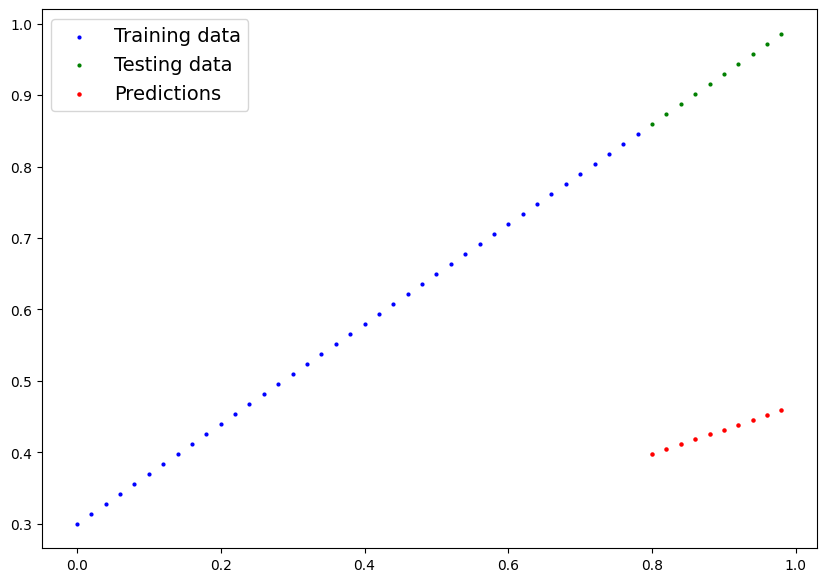

In [22]:
plot_predictions(predictions=y_preds) # At 1 epoch

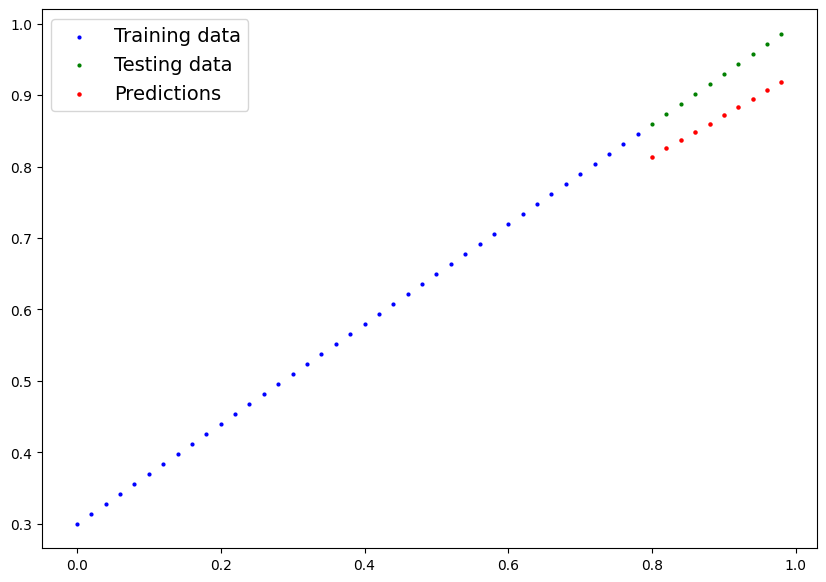

In [51]:
plot_predictions(predictions=y_preds_new) # At 100 epochs

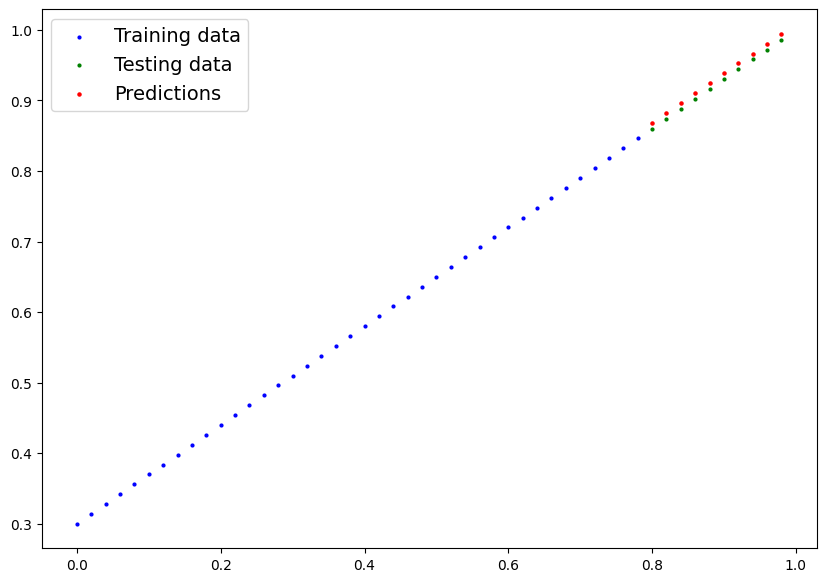

In [23]:
plot_predictions(predictions=y_preds_new) # At 1000 epochs (same at 200 also)

In [24]:
loss_values

[tensor(0.3129, grad_fn=<MeanBackward0>),
 tensor(0.1977, grad_fn=<MeanBackward0>),
 tensor(0.0891, grad_fn=<MeanBackward0>),
 tensor(0.0531, grad_fn=<MeanBackward0>),
 tensor(0.0454, grad_fn=<MeanBackward0>),
 tensor(0.0417, grad_fn=<MeanBackward0>),
 tensor(0.0382, grad_fn=<MeanBackward0>),
 tensor(0.0348, grad_fn=<MeanBackward0>),
 tensor(0.0313, grad_fn=<MeanBackward0>),
 tensor(0.0279, grad_fn=<MeanBackward0>),
 tensor(0.0245, grad_fn=<MeanBackward0>),
 tensor(0.0210, grad_fn=<MeanBackward0>),
 tensor(0.0176, grad_fn=<MeanBackward0>),
 tensor(0.0142, grad_fn=<MeanBackward0>),
 tensor(0.0107, grad_fn=<MeanBackward0>),
 tensor(0.0073, grad_fn=<MeanBackward0>),
 tensor(0.0039, grad_fn=<MeanBackward0>),
 tensor(0.0089, grad_fn=<MeanBackward0>),
 tensor(0.0089, grad_fn=<MeanBackward0>),
 tensor(0.0089, grad_fn=<MeanBackward0>)]

In [26]:
import numpy as np
training_loss_values = torch.tensor(loss_values).numpy()#converting tensor to numpy and removing that grad component
training_loss_values, test_loss_values

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

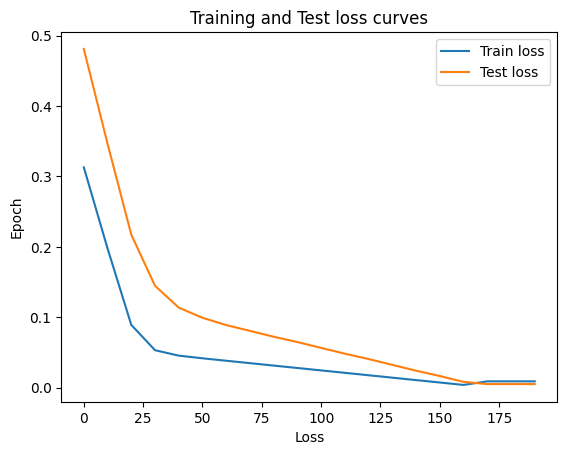

In [27]:
# epoch_count, loss_values, test_loss_values

plt.plot(epoch_count, training_loss_values, label = "Train loss") #loss_values is the trian_loss_values 
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Training and Test loss curves")
plt.xlabel("Loss")
plt.ylabel("Epoch")
plt.legend();

* **`Dropout (The Regularizer)`**: It is a technique that prevent a neural network from overrfitting(memorizing the training data).

  - `model.train()`: It randomly turns off neurons in a layer(so they dont contribute to forward pass and backward pass grad is 0). Its done to ensure to ensure a single neuron isnt too powerful to influence the results as it may stop in next pass. So network learns co-dependencies and redundant pathways.
    
  - `model.eval()`: All neurons are active as we want the best performance from our network. But the total signals enetering each layer will be high than during training. So PyTorch solves it by scaling down(or scales up activation, using Inverted Dropout by dividing by 1 - p, where p is the dropout rate) weights to balance the math out.

* **`Batch Normalization (The Stabilizer)`**: As the data flows through a deep network, the weights change, which means the  distribution of inputs to the deeper layers constantly shifts. This is called *Internal Covariate Shift*, ans it makes it very hard for deep layers to learn efficiently. BatchNorm fixes this by constantly resetting and stabilizing the distribution of data flowing through the network.

  - `model.train()`: It processes data in mini-layers.
      - Calculate batch statistics: finds mean and variance of current batch.
      - Normalize: shifts scales so that mean=0 and variance=1 for data
      - Scale and Shift: Multiplies by scale parameter($\gamma$) and adds shift parameter($\beta$) to allow undo normalization if different distribution is better it decides.
      - Track History: Keeps record of mean and variance
        
  - `model.eval()`: Pass single model instead of a mini-batch. We cant calculate meaningful mean or variance fromm a single data point. So instead of current mean and variance BatchNorm locks itself and uses global running mean and running variance that it memorized during the trianing phase.

## Saving a model in PyTorch

There are three main methods we should know about for saving and loading models in PyTorch:
1. `torch.save()`: allows us to save a PyTorch object in Python's pickle format
2. `torch.load()`: allows us to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()`: this allows to load a model's saved state dictionary


* In Python, "Pickle" is the native format used for `serializing` and `deserializing` object structures.
  * **Serialization(Pickling)**: The process of converting a living Python object hierarchy(like a dictionary, list, class instance, or even a trained ML model) into a flat `bytestream`(a sequence of bytes).
  * **Deserialization(Unpickling)**: The inverse operation, where a byte stream is parsed back into a fully functional, identical Python object in memory.




In [28]:
# ## Pickling example

# import pickle

# # A complex Python dictionary containg different datatypes
# data = {
#     'model name': 'LinearRegression',
#     'weigts': [0.34, 0.12, -0.95],
#     'is_trained': True
# }

# # --- PICKLING (Serialization) ---
# # 'wb' mode stands for writing in binary format
# with open('model_data.pkl', 'wb') as file:
#     pickle.dump(data, file)

# # --- UNPICKLING (Deserialization) ---
# # 'rb' mode stands for reading in binary format
# with open('model_data.pkl', 'rb') as file:
#     loaded_data = pickle.load(file)

# print(loaded_data)
# # Output: {'model name': 'LinearRegression', 'weigts': [0.34, 0.12, -0.95], 'is_trained': True}


# Pickle handles complex types (unlike text based formats like JSON or CSV), it can handle any Python object.
# State Retension: It captures the exact internal state of an object, making it incredibly popular for saving checkpoints of trained
#                 ML models or processing pipelines

# Disadvantage: Scurity Threat(while pickle.load() especially), Python specific(non - interoperable across different languages), version compatibility

In [30]:
# Saving our PyTorch model
from pathlib import Path # pathlib is the python library that deals with file paths

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True) 

# parents = True: This flag instructs the method to create all missing immediate parent directories. 
#                 Without this if parent folder not present FileNotFound error will be raised.
# exist_ok = True: if the  folder exist dont throw error FileExistsError

# 2. Create model save path
MODEL_NAME = "mrdbourke_01_pytorch_workflow_model_0.pth"# PyTorch objects usually have the extension .pth(/.pt)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# MODEL_SAVE_PATH # Output: PosixPath('models/mrdbourke_01_pytorch_workflow_model_0.pth')

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(), #the pytorch object that we are saving
          f = MODEL_SAVE_PATH) #file path(where .pth file to be stored)


# Here we are saving the trained model learned parameters, it gives us the most flexibiity so its recommended
# But the whole model can be saved using torch.save(model, PATH) but as the data is saved in pickle format, the serialized data is 
#     bound to the specific classes and exact directory structure used when model is saved. Due to this during load
#     time our code can break when used in other projects or after refactors.

Saving model to: models/mrdbourke_01_pytorch_workflow_model_0.pth


In [31]:
# Check the saved models
!ls -l models

total 4
-rw-r--r-- 1 root root 2261 May 16 14:51 mrdbourke_01_pytorch_workflow_model_0.pth


### Loading a PyTorch model

Since we saved our model's `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [32]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH)) 

# as all models are submodules under nn.Module in torch.nn.Module.load_state_dict() we can directly call model.load_state_dict()

<All keys matched successfully>

In [34]:
loaded_model_0.state_dict() #Matching perfectly original model and loaded model

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [36]:
# Making some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [37]:
# Make some models preds
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [38]:
# Compare loaded(saved) model preds with original model preds
loaded_model_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [39]:
# Device-agnostic code is software designed to function correctl across different hardware pplatforms, operating systems,
#   or data formats without requiring modification for each specific environment.
# In case of deeplearining frameworks like PyTorch, it refers to code that automatically detects(torch.device()) and utilizes 
#   available hardware resources like CPU, GPU, TPU ensuring the model and data run seamlessly across diffent hardware without modification.

# Kind of "the capacity of a computing component to work with various systems without requiring any particular adaptations"

## 6. Putting it all together(Rehearse the above steps)

In [40]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.10.0+cpu'

Create device-agnostic code.

This means if we've got access to a GPU, our code will use it (for potentially faster computing)
If no GPU available, the code will by default be run using CPU.

In [41]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [42]:
!nvidia-smi #Run if we're using GPU

/bin/bash: line 1: nvidia-smi: command not found


### 6.1 Data

In [48]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) #without unsqueeze errors will pop up
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [49]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [51]:
 def plot_predictions(train_data = X_train,
                      train_labels = y_train,
                      test_data = X_test,
                      test_labels = y_test,
                      predictions = None):
    
     plt.figure(figsize = (10,7))
     
     plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

     plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Testing data")

     # Are there predictions?
     if predictions is not None:  
         plt.scatter(test_data, predictions, c = "r", s = 5, label = "Predictions")  
                                                                             
     # Show the legend
     plt.legend(prop={"size":14}); 

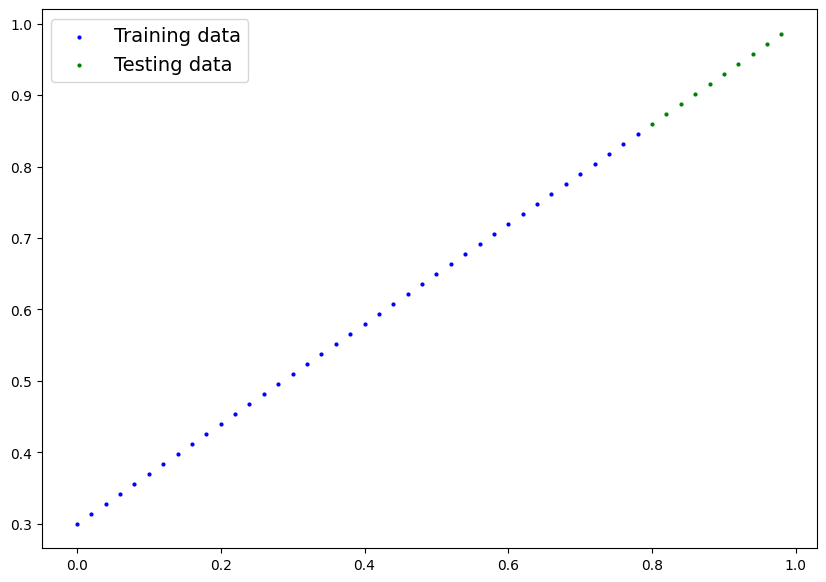

In [52]:
# Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 Building a PyTorch Linear Model

In [54]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating model parameters instead of creating them ourselves 
        # linear layer is also called linear transform, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features=1,  #input 1 feature(X_train) (Creating 1 layer with 1 i/p and 1 o/p)
                                     out_features=1)  #output 1 feature(y_train)
                                     #bias is by defalut True, we can set it to false
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)

model_1 = LinearRegressionModelV2() #create an instance
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [55]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [56]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device #iif gpu on then type=cuda, index=0

device(type='cpu')

### 6.3 Training

For training we need:
1. Loss Function
2. Optimizer
3. Training loop
4. Testing loop

In [58]:
# Setup loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(), lr=0.01)

In [61]:
# Training loop
torch.manual_seed(42)

epochs = 200

# Put data on the target device (device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ## Testing loop
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred, y_test)

    # Print out whats happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss(training): {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss(training): 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Loss(training): 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Loss(training): 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss(training): 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Loss(training): 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Loss(training): 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Loss(training): 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Loss(training): 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Loss(training): 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Loss(training): 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss(training): 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Loss(training): 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Loss(trainin

##### By epoch 120 model has learned

In [62]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [63]:
weight, bias

(0.7, 0.3)

### 6.4 Making and evaluating predictions

In [71]:
# Turn model into evaluation mode
model_1.eval()

# Making predictions on the test data
with torch.inference_mode():
    y_pred_new1 = model_1(X_test)

In [91]:
y_pred_new1

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

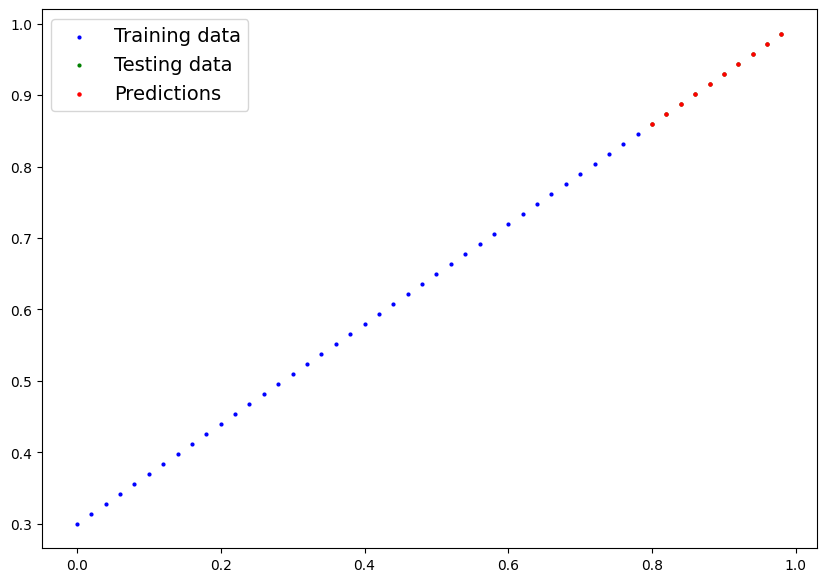

In [74]:
plot_predictions(predictions = y_pred_new.cpu())

### Saving and loading a trained model

In [86]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True) 

# 2. Create model save path
MODEL_NAME = "mrdbourke_01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),
          f = MODEL_SAVE_PATH)

Saving model to: models/mrdbourke_01_pytorch_workflow_model_1.pth


In [87]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [88]:
# Load a PyTorch model

# Create a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model_1 state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [89]:
next(loaded_model_1.parameters()).device 
#loaded_model_1.parameters() returns a generator object not a list, 
# next() grabs the very first parameter tensor (usually weights) and stop there and 
#     on basis on those tensors check on which device they are present in the memory

device(type='cpu')

In [92]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_pred_new1 == loaded_model_1_preds
# y_preds == loaded_model_1.preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])